# Playground Series S6E4 - CatBoost Tuning

This notebook moves from baseline comparison into focused CatBoost experimentation. It uses stratified cross-validation, compares feature variants, tunes a compact set of CatBoost parameters, and writes a tuned submission file.

## 1. Setup

Load the Kaggle modeling stack and define shared experiment controls. The defaults are practical for iteration; increase folds or add parameter sets after the first run is stable.

In [1]:
from pathlib import Path
from IPython.display import display

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 140)
pd.set_option('display.float_format', '{:,.5f}'.format)

sns.set_theme(style='whitegrid', context='notebook')
VIRIDIS_CMAP = 'viridis'
RANDOM_STATE = 42
N_SPLITS = 3
RUN_FULL_CV = True
MAKE_SUBMISSION = True

## 2. Data Loading

Load the Kaggle competition files and infer the ID and target columns from `sample_submission.csv`.

In [2]:
INPUT_ROOT = Path('/kaggle/input')

if not INPUT_ROOT.exists():
    raise RuntimeError('This notebook is intended to run on Kaggle, where /kaggle/input is available.')

def find_file(filename: str) -> Path:
    matches = sorted(INPUT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(f'Could not find {filename} under {INPUT_ROOT}. Attach the competition data.')
    if len(matches) > 1:
        print(f'Found multiple {filename} files. Using: {matches[0]}')
    return matches[0]

train = pd.read_csv(find_file('train.csv'))
test = pd.read_csv(find_file('test.csv'))
sample_submission = pd.read_csv(find_file('sample_submission.csv'))

target_col = sample_submission.columns[-1]
id_col = sample_submission.columns[0]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train[target_col])
class_names = label_encoder.classes_.tolist()

print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')
print('classes:', class_names)
display(train[target_col].value_counts(normalize=True).mul(100).rename('target_pct').to_frame())

train shape: (630000, 21)
test shape: (270000, 20)
classes: ['High', 'Low', 'Medium']


,target_pct
Irrigation_Need,
Low,58.71698
Medium,37.94825
High,3.33476


## 3. Feature Variants

Compare raw competition features against EDA-driven interaction and threshold features. The baseline notebook showed that interactions contribute, while EDA showed strong threshold behavior in soil moisture, rainfall, temperature, and wind speed.

### 3.1 Base and Interaction Features

Create the same interaction features used in the baseline notebook so tuning can compare against the previous best model.

In [3]:
base_feature_cols = [c for c in train.columns if c not in {id_col, target_col}]

INTERACTION_PAIRS = [
    ('Crop_Growth_Stage', 'Mulching_Used'),
    ('Crop_Growth_Stage', 'Water_Source'),
    ('Crop_Growth_Stage', 'Irrigation_Type'),
]

def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for left, right in INTERACTION_PAIRS:
        if left in out.columns and right in out.columns:
            out[f'{left}__x__{right}'] = out[left].astype(str) + '__' + out[right].astype(str)
    return out

train_interactions = add_interaction_features(train)
test_interactions = add_interaction_features(test)

interaction_feature_cols = [c for c in train_interactions.columns if c not in {id_col, target_col}]
interaction_cols = [c for c in interaction_feature_cols if '__x__' in c]

print('Base feature count:', len(base_feature_cols))
print('Interaction feature count:', len(interaction_feature_cols))
print('Interaction columns:', interaction_cols)

Base feature count: 19
Interaction feature count: 22
Interaction columns: ['Crop_Growth_Stage__x__Mulching_Used', 'Crop_Growth_Stage__x__Water_Source', 'Crop_Growth_Stage__x__Irrigation_Type']


### 3.2 Threshold Features

Add compact threshold indicators inspired by EDA. These may help if CatBoost benefits from explicit high-risk cut points, but they should be validated rather than assumed useful.

In [4]:
def add_threshold_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'Soil_Moisture' in out.columns:
        out['Soil_Moisture_le_26'] = (out['Soil_Moisture'] <= 26.22).astype('int8')
        out['Soil_Moisture_le_20'] = (out['Soil_Moisture'] <= 20.50).astype('int8')
    if 'Rainfall_mm' in out.columns:
        out['Rainfall_le_644'] = (out['Rainfall_mm'] <= 643.77).astype('int8')
    if 'Temperature_C' in out.columns:
        out['Temperature_ge_30'] = (out['Temperature_C'] >= 30.21).astype('int8')
    if 'Wind_Speed_kmh' in out.columns:
        out['Wind_Speed_ge_10_5'] = (out['Wind_Speed_kmh'] >= 10.48).astype('int8')
    return out

train_full = add_threshold_features(train_interactions)
test_full = add_threshold_features(test_interactions)

threshold_cols = [c for c in train_full.columns if c not in train_interactions.columns]
full_feature_cols = [c for c in train_full.columns if c not in {id_col, target_col}]

print('Threshold columns:', threshold_cols)
print('Full feature count:', len(full_feature_cols))

Threshold columns: ['Soil_Moisture_le_26', 'Soil_Moisture_le_20', 'Rainfall_le_644', 'Temperature_ge_30', 'Wind_Speed_ge_10_5']
Full feature count: 27


## 4. Evaluation Utilities

Define reusable cross-validation, metric, and plotting helpers. Macro F1 and `High` recall remain important because the `High` class is rare.

In [5]:
def get_categorical_columns(df: pd.DataFrame, feature_cols: list[str]) -> list[str]:
    return [c for c in feature_cols if df[c].dtype == 'object' or str(df[c].dtype).startswith('category')]

def make_pool(df: pd.DataFrame, feature_cols: list[str], target=None) -> Pool:
    cat_cols = get_categorical_columns(df, feature_cols)
    cat_indices = [feature_cols.index(c) for c in cat_cols]
    return Pool(df[feature_cols], label=target, cat_features=cat_indices)

def evaluate_fold(y_true, pred, proba):
    row = {
        'accuracy': accuracy_score(y_true, pred),
        'macro_f1': f1_score(y_true, pred, average='macro'),
        'weighted_f1': f1_score(y_true, pred, average='weighted'),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'log_loss': log_loss(y_true, proba, labels=np.arange(len(class_names))),
    }
    report = classification_report(y_true, pred, target_names=class_names, output_dict=True, zero_division=0)
    for label in class_names:
        row[f'{label}_precision'] = report[label]['precision']
        row[f'{label}_recall'] = report[label]['recall']
        row[f'{label}_f1'] = report[label]['f1-score']
    return row

def summarize_cv(results: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [c for c in results.columns if c not in {'experiment', 'fold'}]
    summary = results.groupby('experiment')[metric_cols].agg(['mean', 'std'])
    return summary.sort_values(('macro_f1', 'mean'), ascending=False)

def plot_confusion(y_true, pred, title):
    cm = confusion_matrix(y_true, pred, labels=np.arange(len(class_names)))
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=VIRIDIS_CMAP, xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{title} - Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap=VIRIDIS_CMAP, xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{title} - Row Normalized')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

## 5. Experiment Grid

Start with a compact set of CatBoost configurations. The goal is not exhaustive search yet; it is to understand whether depth, regularization, class weighting, and feature variants improve over the baseline.

In [6]:
BASE_CATBOOST_PARAMS = {
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1',
    'random_seed': RANDOM_STATE,
    'verbose': False,
    'allow_writing_files': False,
    'thread_count': -1,
}

class_counts = np.bincount(y)
class_weights = (len(y) / (len(class_counts) * class_counts)).tolist()
print('Class weights by encoded class:', dict(zip(class_names, class_weights)))

EXPERIMENTS = [
    {
        'experiment': 'baseline_interactions',
        'train_df': train_interactions,
        'test_df': test_interactions,
        'feature_cols': interaction_feature_cols,
        'params': {
            **BASE_CATBOOST_PARAMS,
            'iterations': 600,
            'learning_rate': 0.06,
            'depth': 7,
            'l2_leaf_reg': 3.0,
        },
    },
    {
        'experiment': 'deeper_interactions',
        'train_df': train_interactions,
        'test_df': test_interactions,
        'feature_cols': interaction_feature_cols,
        'params': {
            **BASE_CATBOOST_PARAMS,
            'iterations': 800,
            'learning_rate': 0.045,
            'depth': 8,
            'l2_leaf_reg': 4.0,
            'random_strength': 1.0,
        },
    },
    {
        'experiment': 'regularized_interactions',
        'train_df': train_interactions,
        'test_df': test_interactions,
        'feature_cols': interaction_feature_cols,
        'params': {
            **BASE_CATBOOST_PARAMS,
            'iterations': 900,
            'learning_rate': 0.04,
            'depth': 7,
            'l2_leaf_reg': 8.0,
            'random_strength': 1.5,
            'bagging_temperature': 0.5,
        },
    },
    {
        'experiment': 'weighted_interactions',
        'train_df': train_interactions,
        'test_df': test_interactions,
        'feature_cols': interaction_feature_cols,
        'params': {
            **BASE_CATBOOST_PARAMS,
            'iterations': 700,
            'learning_rate': 0.05,
            'depth': 7,
            'l2_leaf_reg': 5.0,
            'class_weights': class_weights,
        },
    },
    {
        'experiment': 'threshold_features',
        'train_df': train_full,
        'test_df': test_full,
        'feature_cols': full_feature_cols,
        'params': {
            **BASE_CATBOOST_PARAMS,
            'iterations': 800,
            'learning_rate': 0.045,
            'depth': 7,
            'l2_leaf_reg': 5.0,
            'random_strength': 1.0,
        },
    },
]

pd.DataFrame([
    {'experiment': e['experiment'], 'n_features': len(e['feature_cols']), **{k: v for k, v in e['params'].items() if k not in {'loss_function', 'eval_metric', 'verbose', 'allow_writing_files', 'thread_count'}}}
    for e in EXPERIMENTS
])

Class weights by encoded class: {'High': 9.995716121662145, 'Low': 0.5676949153458749, 'Medium': 0.8783891180136694}


,experiment,n_features,random_seed,iterations,learning_rate,depth,l2_leaf_reg,random_strength,bagging_temperature,class_weights
0,baseline_interactions,22,42,600,0.06000,7,3.00000,NaN,NaN,NaN
1,deeper_interactions,22,42,800,0.04500,8,4.00000,1.00000,NaN,NaN
2,regularized_interactions,22,42,900,0.04000,7,8.00000,1.50000,0.50000,NaN
3,weighted_interactions,22,42,700,0.05000,7,5.00000,NaN,NaN,"[9.995716121662145, 0.5676949153458749, 0.8783..."
4,threshold_features,27,42,800,0.04500,7,5.00000,1.00000,NaN,NaN


## 6. Stratified Cross-Validation

Run stratified cross-validation for each experiment. The out-of-fold predictions are retained for diagnostics, including confusion matrices and class-level reports.

In [7]:
cv_rows = []
oof_predictions = {}
oof_probabilities = {}
trained_fold_models = {}

if RUN_FULL_CV:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for exp in EXPERIMENTS:
        name = exp['experiment']
        df = exp['train_df']
        feature_cols = exp['feature_cols']
        params = exp['params']
        print(f'Running {name} with {len(feature_cols)} features')

        oof_pred = np.zeros(len(df), dtype=int)
        oof_proba = np.zeros((len(df), len(class_names)), dtype=float)
        fold_models = []

        for fold, (tr_idx, va_idx) in enumerate(skf.split(df[feature_cols], y), start=1):
            train_pool = make_pool(df.iloc[tr_idx], feature_cols, y[tr_idx])
            valid_pool = make_pool(df.iloc[va_idx], feature_cols, y[va_idx])
            model = CatBoostClassifier(**params)
            model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
            proba = model.predict_proba(valid_pool)
            pred = proba.argmax(axis=1)

            oof_pred[va_idx] = pred
            oof_proba[va_idx] = proba
            row = evaluate_fold(y[va_idx], pred, proba)
            row.update({'experiment': name, 'fold': fold})
            cv_rows.append(row)
            fold_models.append(model)
            print(f'  fold {fold}: macro_f1={row["macro_f1"]:.5f}, log_loss={row["log_loss"]:.5f}, High_recall={row.get("High_recall", np.nan):.5f}')

            del train_pool, valid_pool, model
            gc.collect()

        oof_predictions[name] = oof_pred
        oof_probabilities[name] = oof_proba
        trained_fold_models[name] = fold_models

    cv_results = pd.DataFrame(cv_rows)
    display(cv_results)
    cv_summary = summarize_cv(cv_results)
    display(cv_summary)
else:
    cv_results = pd.DataFrame()
    cv_summary = pd.DataFrame()
    print('Cross-validation disabled. Set RUN_FULL_CV = True to run experiments.')

Running baseline_interactions with 22 features
  fold 1: macro_f1=0.97032, log_loss=0.06187, High_recall=0.91189
  fold 2: macro_f1=0.97000, log_loss=0.06086, High_recall=0.91475
  fold 3: macro_f1=0.96949, log_loss=0.05991, High_recall=0.91218
Running deeper_interactions with 22 features
  fold 1: macro_f1=0.97061, log_loss=0.06003, High_recall=0.91304
  fold 2: macro_f1=0.96968, log_loss=0.06076, High_recall=0.91347
  fold 3: macro_f1=0.96938, log_loss=0.05969, High_recall=0.91161
Running regularized_interactions with 22 features
  fold 1: macro_f1=0.97025, log_loss=0.06215, High_recall=0.91061
  fold 2: macro_f1=0.96960, log_loss=0.06114, High_recall=0.91375
  fold 3: macro_f1=0.96929, log_loss=0.06015, High_recall=0.91175
Running weighted_interactions with 22 features
  fold 1: macro_f1=0.95782, log_loss=0.07342, High_recall=0.94445
  fold 2: macro_f1=0.95731, log_loss=0.07536, High_recall=0.94759
  fold 3: macro_f1=0.95831, log_loss=0.07453, High_recall=0.94617
Running threshold_f

,accuracy,macro_f1,weighted_f1,balanced_accuracy,log_loss,High_precision,High_recall,High_f1,Low_precision,Low_recall,Low_f1,Medium_precision,Medium_recall,Medium_f1,experiment,fold
0,0.98507,0.97032,0.98500,0.96095,0.06187,0.97007,0.91189,0.94009,0.98600,0.99530,0.99063,0.98485,0.97566,0.98023,baseline_interactions,1
1,0.98464,0.97000,0.98458,0.96149,0.06086,0.96680,0.91475,0.94005,0.98552,0.99509,0.99028,0.98476,0.97461,0.97966,baseline_interactions,2
2,0.98452,0.96949,0.98445,0.96071,0.05991,0.96685,0.91218,0.93872,0.98606,0.99446,0.99024,0.98358,0.97549,0.97952,baseline_interactions,3
3,0.98509,0.97061,0.98502,0.96132,0.06003,0.97070,0.91304,0.94099,0.98597,0.99526,0.99060,0.98489,0.97567,0.98026,deeper_interactions,1
4,0.98456,0.96968,0.98449,0.96103,0.06076,0.96646,0.91347,0.93922,0.98549,0.99508,0.99026,0.98462,0.97454,0.97955,deeper_interactions,2
5,0.98453,0.96938,0.98446,0.96053,0.05969,0.96669,0.91161,0.93834,0.98604,0.99453,0.99027,0.98364,0.97546,0.97953,deeper_interactions,3
6,0.98504,0.97025,0.98497,0.96054,0.06215,0.97122,0.91061,0.93994,0.98596,0.99530,0.99061,0.98474,0.97569,0.98020,regularized_interactions,1
7,0.98454,0.96960,0.98448,0.96110,0.06114,0.96574,0.91375,0.93903,0.98550,0.99505,0.99025,0.98461,0.97450,0.97953,regularized_interactions,2
8,0.98450,0.96929,0.98443,0.96056,0.06015,0.96611,0.91175,0.93814,0.98607,0.99447,0.99025,0.98355,0.97546,0.97949,regularized_interactions,3
9,0.98179,0.95782,0.98185,0.96826,0.07342,0.87371,0.94445,0.90771,0.98625,0.99375,0.98999,0.98516,0.96657,0.97578,weighted_interactions,1


accuracy         macro_f1         weighted_f1  \
                             mean     std     mean     std        mean   
experiment                                                               
baseline_interactions     0.98474 0.00029  0.96994 0.00041     0.98468   
deeper_interactions       0.98473 0.00031  0.96989 0.00064     0.98466   
threshold_features        0.98471 0.00029  0.96974 0.00048     0.98464   
regularized_interactions  0.98469 0.00030  0.96971 0.00049     0.98462   
weighted_interactions     0.98166 0.00015  0.95781 0.00050     0.98172   

                                 balanced_accuracy         log_loss          \
                             std              mean     std     mean     std   
experiment                                                                    
baseline_interactions    0.00029           0.96105 0.00040  0.06088 0.00098   
deeper_interactions      0.00031           0.96096 0.00040  0.06016 0.00055   
threshold_features       0.00029           0.96068 0.00029  0.06146 0.00130   
regularized_interactions 0.00030           0.96073 0.00032  0.06115 0.00100   
weighted_interactions    0.00015           0.96866 0.00036  0.07444 0.00097   

                         High_precision         High_recall         High_f1  \
                                   mean     std        mean     std    mean   
experiment                                                                    
baseline_interactions           0.96791 0.00188     0.91294 0.00157 0.93962   
deeper_interactions             0.96795 0.00239     0.91270 0.00097 0.93951   
threshold_features              0.96797 0.00257     0.91185 0.00133 0.93907   
regularized_interactions        0.96769 0.00306     0.91204 0.00159 0.93904   
weighted_interactions           0.87284 0.00322     0.94607 0.00157 0.90798   

                                 Low_precision         Low_recall          \
                             std          mean     std       mean     std   
experiment                                                                  
baseline_interactions    0.00078       0.98586 0.00029    0.99495 0.00044   
deeper_interactions      0.00135       0.98583 0.00030    0.99496 0.00038   
threshold_features       0.00093       0.98582 0.00027    0.99500 0.00038   
regularized_interactions 0.00090       0.98584 0.00030    0.99494 0.00043   
weighted_interactions    0.00139       0.98616 0.00023    0.99360 0.00027   

                          Low_f1         Medium_precision          \
                            mean     std             mean     std   
experiment                                                          
baseline_interactions    0.99038 0.00021          0.98440 0.00071   
deeper_interactions      0.99037 0.00019          0.98438 0.00066   
threshold_features       0.99039 0.00020          0.98437 0.00060   
regularized_interactions 0.99037 0.00020          0.98430 0.00065   
weighted_interactions    0.98986 0.00011          0.98507 0.00043   

                         Medium_recall         Medium_f1          
                                  mean     std      mean     std  
experiment                                                        
baseline_interactions          0.97525 0.00056   0.97980 0.00038  
deeper_interactions            0.97522 0.00060   0.97978 0.00041  
threshold_features             0.97520 0.00056   0.97976 0.00039  
regularized_interactions       0.97522 0.00063   0.97974 0.00040  
weighted_interactions          0.96631 0.00073   0.97560 0.00021

## 7. Experiment Diagnostics

Inspect the best experiment from cross-validation. Focus on macro F1, log loss, and the `High` class precision/recall tradeoff.

Best experiment by mean macro F1: baseline_interactions
              precision    recall  f1-score   support

        High     0.9679    0.9129    0.9396     21009
         Low     0.9859    0.9950    0.9904    369917
      Medium     0.9844    0.9753    0.9798    239074

    accuracy                         0.9847    630000
   macro avg     0.9794    0.9610    0.9699    630000
weighted avg     0.9847    0.9847    0.9847    630000



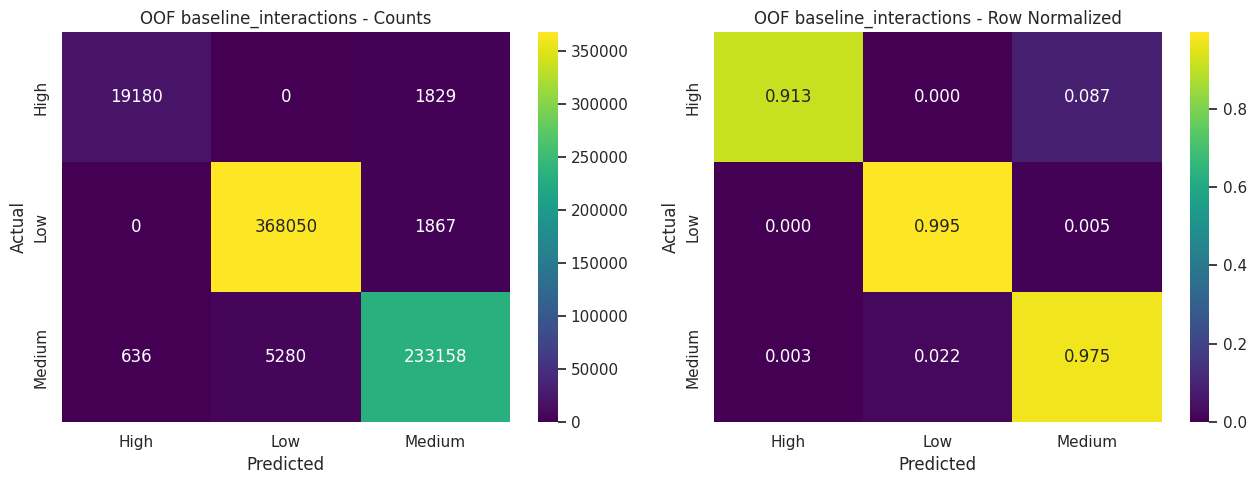

,experiment,fold,macro_f1,log_loss,balanced_accuracy,High_recall,Low_recall,Medium_recall
0,baseline_interactions,1,0.97032,0.06187,0.96095,0.91189,0.99530,0.97566
1,baseline_interactions,2,0.97000,0.06086,0.96149,0.91475,0.99509,0.97461
2,baseline_interactions,3,0.96949,0.05991,0.96071,0.91218,0.99446,0.97549
3,deeper_interactions,1,0.97061,0.06003,0.96132,0.91304,0.99526,0.97567
4,deeper_interactions,2,0.96968,0.06076,0.96103,0.91347,0.99508,0.97454
5,deeper_interactions,3,0.96938,0.05969,0.96053,0.91161,0.99453,0.97546
6,regularized_interactions,1,0.97025,0.06215,0.96054,0.91061,0.99530,0.97569
7,regularized_interactions,2,0.96960,0.06114,0.96110,0.91375,0.99505,0.97450
8,regularized_interactions,3,0.96929,0.06015,0.96056,0.91175,0.99447,0.97546
12,threshold_features,1,0.97023,0.06292,0.96058,0.91075,0.99532,0.97568


In [8]:
if RUN_FULL_CV and not cv_results.empty:
    best_experiment = cv_results.groupby('experiment')['macro_f1'].mean().sort_values(ascending=False).index[0]
    print('Best experiment by mean macro F1:', best_experiment)
    print(classification_report(y, oof_predictions[best_experiment], target_names=class_names, digits=4))
    plot_confusion(y, oof_predictions[best_experiment], f'OOF {best_experiment}')

    metric_view = cv_results[['experiment', 'fold', 'macro_f1', 'log_loss', 'balanced_accuracy'] + [f'{label}_recall' for label in class_names]]
    display(metric_view.sort_values(['experiment', 'fold']))
else:
    best_experiment = EXPERIMENTS[0]['experiment']
    print('Using default best experiment because CV results are not available:', best_experiment)

## 8. Feature Importance

Fit the selected configuration on a stratified holdout split for feature interpretation. This confirms whether tuning still relies on the same agronomic drivers identified by EDA and the baseline notebook.

,feature,importance
0,Soil_Moisture,27.81262
1,Crop_Growth_Stage,26.29354
2,Mulching_Used,11.80926
3,Temperature_C,11.77150
4,Wind_Speed_kmh,11.66560
5,Rainfall_mm,3.07089
6,Crop_Growth_Stage__x__Mulching_Used,2.65059
7,Humidity,1.00335
8,Crop_Growth_Stage__x__Irrigation_Type,0.95070
9,Crop_Growth_Stage__x__Water_Source,0.77256


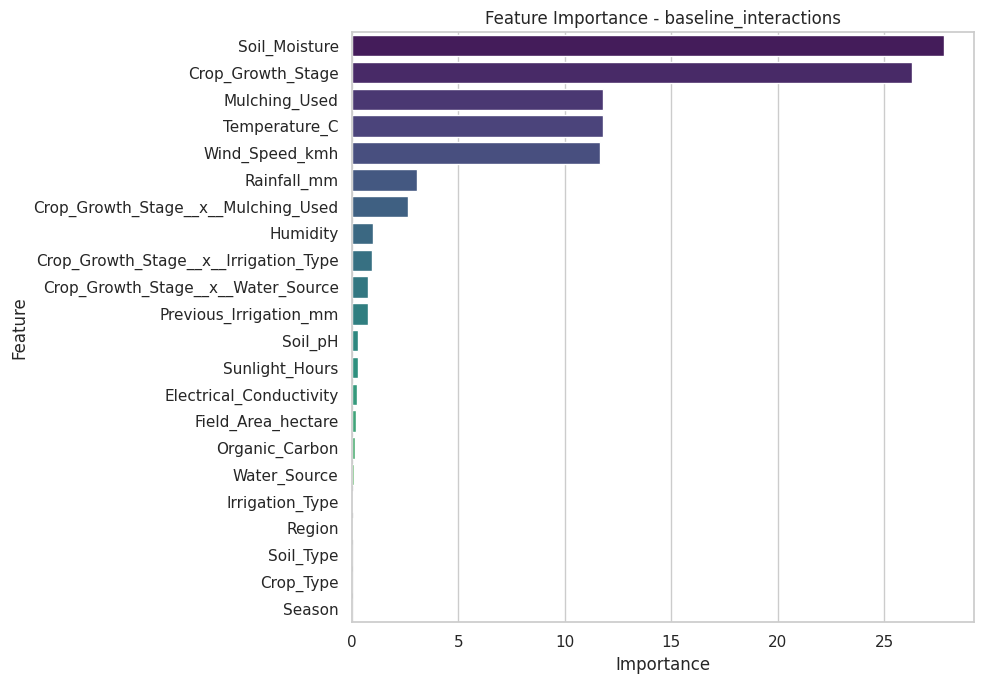

In [9]:
selected_exp = next(e for e in EXPERIMENTS if e['experiment'] == best_experiment)
selected_df = selected_exp['train_df']
selected_features = selected_exp['feature_cols']
selected_params = selected_exp['params']

tr_idx, va_idx = train_test_split(
    np.arange(len(selected_df)),
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

holdout_model = CatBoostClassifier(**selected_params)
holdout_model.fit(
    make_pool(selected_df.iloc[tr_idx], selected_features, y[tr_idx]),
    eval_set=make_pool(selected_df.iloc[va_idx], selected_features, y[va_idx]),
    use_best_model=True,
)

importance = holdout_model.get_feature_importance(prettified=True).rename(
    columns={'Feature Id': 'feature', 'Importances': 'importance'}
)
display(importance.head(30))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance.head(25), x='importance', y='feature', hue='feature', palette=VIRIDIS_CMAP, legend=False)
plt.title(f'Feature Importance - {best_experiment}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 9. Final Training and Submission

Train the selected CatBoost configuration on the full training data and create a tuned `submission.csv`. Review the prediction distribution before submitting.

In [10]:
if MAKE_SUBMISSION:
    final_model = CatBoostClassifier(**selected_params)
    final_model.fit(make_pool(selected_df, selected_features, y))

    selected_test_df = selected_exp['test_df']
    test_pool = make_pool(selected_test_df, selected_features)
    test_pred = final_model.predict(test_pool)
    if test_pred.ndim > 1:
        test_pred = test_pred.reshape(-1)
    test_pred = test_pred.astype(int)
    test_labels = label_encoder.inverse_transform(test_pred)

    submission = sample_submission.copy()
    submission[target_col] = test_labels
    submission.to_csv('submission.csv', index=False)

    display(submission.head())
    display(submission[target_col].value_counts(normalize=True).mul(100).rename('prediction_pct').to_frame())
    print('Wrote submission.csv using:', best_experiment)
else:
    print('Submission creation disabled.')

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


,prediction_pct
Irrigation_Need,
Low,59.22593
Medium,37.59370
High,3.18037


Wrote submission.csv using: baseline_interactions


## 10. Tuning Summary and Next Steps

Record the best cross-validation result, leaderboard score, selected parameters, and whether interaction or threshold features improved the model.

Current tuning interpretation:

- `baseline_interactions` was the best cross-validation experiment by mean macro F1: `0.96994`.
- `deeper_interactions` had slightly better mean log loss (`0.06016` vs `0.06088`) but did not improve macro F1.
- Threshold features did not improve performance over the interaction baseline.
- Class weighting improved `High` recall to about `0.946`, but it reduced macro F1 and worsened log loss.
- The validated public leaderboard score from the reused tuning submission is `0.96094`.

Recommended next experiment: use the current submission as the stable baseline, then test a compact ensemble or calibration workflow rather than rerunning a broad CatBoost grid.